In [12]:
import os

import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

import plotly.graph_objects as go


In [2]:
final_image = np.load("vanguard/notebooks/tries/sample.npy")
np.min(final_image), np.max(final_image)

(np.float16(0.0), np.float16(1.0))

In [3]:
np.isclose(np.sum(final_image, axis=0), 1, rtol=0.002).all()

np.True_

In [4]:
vessels = final_image[1]

In [5]:
print("Shape:", vessels.shape)
print("Data type:", vessels.dtype)
print("Min:", np.min(vessels))
print("Max:", np.max(vessels))
print("Unique values (sample):", np.unique(vessels)[:10])

Shape: (448, 448, 160)
Data type: float16
Min: 0.0
Max: 1.0
Unique values (sample): [0.0e+00 6.0e-08 1.2e-07 1.8e-07 2.4e-07 3.0e-07 3.6e-07 4.2e-07 4.8e-07
 5.4e-07]


In [6]:
import sys, os
sys.path.append(os.path.abspath("vanguard/notebooks"))
from skeleton3d import skeletonize3d, _OFFSETS_3D

In [7]:
skeleton = skeletonize3d(vessels, threshold=0.90)

In [8]:
print("Shape:", skeleton.shape)
print("Data type:", skeleton.dtype)
print("Min:", np.min(skeleton))
print("Max:", np.max(skeleton))
print("Unique values (sample):", np.unique(skeleton)[:10])

Shape: (448, 448, 160)
Data type: uint32
Min: 0
Max: 37748768
Unique values (sample): [ 0  1  2  4  8 12 16 32 40 64]


In [9]:
def edges_to_segments(edges):
    """
    Convert 3D bitmask edge volume to a list of line segments [(p1, p2), ...]
    where p1,p2 are (z,y,x) coordinates.
    """
    Z, H, W = edges.shape
    segments = []
    for k in range(Z):
        for i in range(H):
            for j in range(W):
                mask = edges[k, i, j]
                if mask == 0:
                    continue
                for b in range(26):
                    if (mask >> b) & 1:
                        dz, dy, dx = _OFFSETS_3D[b]
                        nk, ni, nj = k + dz, i + dy, j + dx
                        # Avoid duplicate segments: only add if neighbor is ahead in lexicographic order
                        if 0 <= nk < Z and 0 <= ni < H and 0 <= nj < W:
                            if (nk, ni, nj) > (k, i, j):
                                segments.append(((j, i, k), (nj, ni, nk)))  # (x,y,z)
    return np.array(segments)


In [10]:
segments = edges_to_segments(skeleton)
print(f"{len(segments)} line segments extracted")

3499 line segments extracted


In [20]:
x0, y0, z0 = segments[:, 0, 0], segments[:, 0, 1], segments[:, 0, 2]
x1, y1, z1 = segments[:, 1, 0], segments[:, 1, 1], segments[:, 1, 2]

# Create line traces (vessels)
lines = [
    go.Scatter3d(
        x=[x0[i], x1[i]],
        y=[y0[i], y1[i]],
        z=[z0[i], z1[i]],
        mode="lines",
        line=dict(color="#9a14b5", width=3),
        opacity=1.0,
        showlegend=False,
    )
    for i in range(len(segments))
]

fig = go.Figure(data=lines)

# Unified minimalist layout
fig.update_layout(
    scene=dict(
        xaxis=dict(showbackground=True, backgroundcolor="#DFD8DE",
                   showgrid=True, zeroline=True, showticklabels=True, title=""),
        yaxis=dict(showbackground=True, backgroundcolor="#DFD8DE",
                   showgrid=True, zeroline=True, showticklabels=True, title=""),
        zaxis=dict(showbackground=True, backgroundcolor="#DFD8DE",
                   showgrid=True, zeroline=True, showticklabels=True, title=""),
        aspectmode="data",
        bgcolor="white",  # background behind the cube
    ),
    paper_bgcolor="white",  # full figure background
    margin=dict(l=0, r=0, b=0, t=0),
)

fig.show()

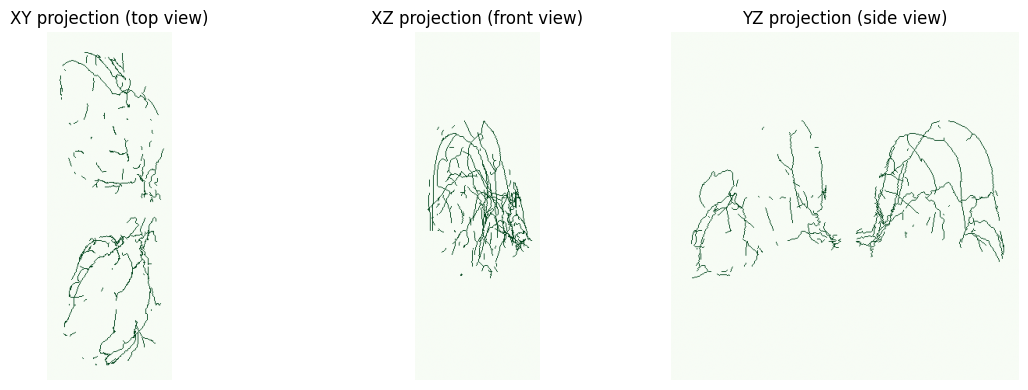

In [22]:
import matplotlib.pyplot as plt

# Projection of nodes
proj_xy = (skeleton > 0).any(axis=0)
proj_xz = (skeleton > 0).any(axis=1)
proj_yz = (skeleton > 0).any(axis=2)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(proj_xy, cmap="Greens")
axs[0].set_title("XY projection (top view)")
axs[1].imshow(proj_xz, cmap="Greens")
axs[1].set_title("XZ projection (front view)")
axs[2].imshow(proj_yz, cmap="Greens")
axs[2].set_title("YZ projection (side view)")
for ax in axs: ax.axis("off")
plt.tight_layout()
plt.show()
